## Legendre Polynomials

The Legendre polynomials arise naturally when solving Laplace’s equation in spherical coordinates. In particular, after separating variables, the angular equation reduces to Legendre’s differential equation:

$$
\frac{d}{dx}\left[(1-x^2)\frac{dP_\ell}{dx}\right]
+
\ell(\ell+1)P_\ell = 0
$$

Its solutions are the Legendre polynomials $P_\ell(x)$, where $\ell = 0,1,2,\dots$.

The first few Legendre polynomials are

$$ P_0(x)=1 $$

$$ P_1(x)=x $$

$$ P_2(x)=\frac12(3x^2-1) $$

$$ P_3(x)=\frac12(5x^3-3x) $$

The Legendre polynomials can be generated using Rodrigues' formula:

$$ P_\ell(x) = \frac{1}{2^\ell \ell!} \frac{d^\ell}{dx^\ell} (x^2-1)^\ell $$

These functions form an orthogonal basis on the interval $[-1,1]$:

$$ \int_{-1}^{1} P_\ell(x)P_m(x)\,dx = 0, \qquad \ell\ne m $$

Below, we plot the first few Legendre polynomials on the interval $[-1,1]$. As the order $\ell$ increases, the functions develop increasingly intricate oscillatory structure while remaining orthogonal over the interval.

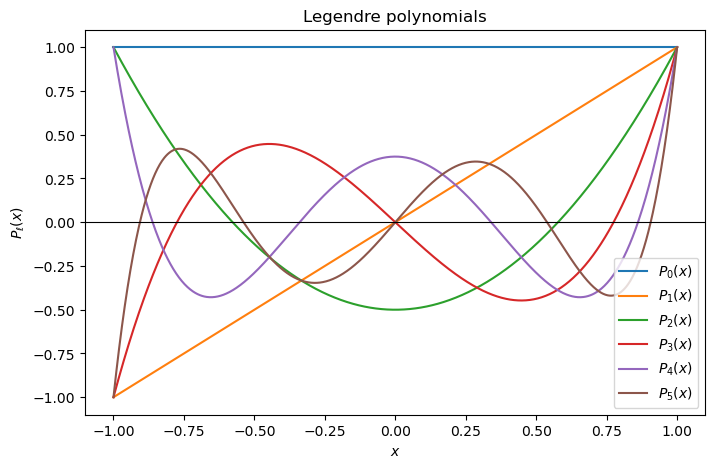

In [50]:
# Legendre polynomials

import numpy as np
import matplotlib.pyplot as plt
import scipy.special as ss

# Create x values on [-1,1]
x = np.linspace(-1, 1, 1000)

# Create figure
fig, ax = plt.subplots(figsize = (8, 5))

# Plot several Legendre polynomials
for ell in range(6):

    P = ss.eval_legendre(ell, x)

    ax.plot(
        x,
        P,
        linewidth = 1.5,
        label = rf"$P_{{{ell}}}(x)$"
    )

# Horizontal axis
ax.axhline(
    0,
    color = "black",
    linewidth = 0.8
)

# Labels
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$P_\ell(x)$")

# Title
ax.set_title("Legendre polynomials")

# Legend
ax.legend()

plt.show()

## Legendre Polynomials as Functions of Angle

The previous plot treats the Legendre polynomials as functions of the variable $x$ on the interval $[-1,1]$. In spherical coordinates, however, this variable is usually related to the polar angle by

$$
x=\cos\theta
$$

This gives the angular functions

$$
P_\ell(\cos\theta)
$$

Plotting these against $\theta$ shows how each Legendre polynomial varies from the north pole of a sphere to the south pole, with

$$
0 \leq \theta \leq \pi
$$

This is the form in which Legendre polynomials naturally appear in spherical-coordinate problems.

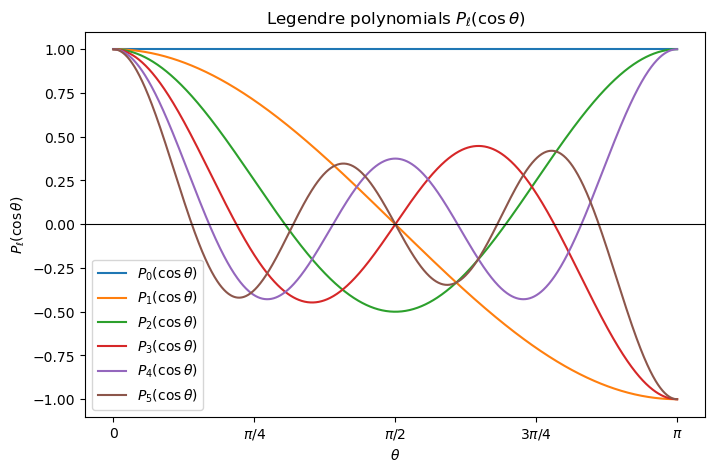

In [1]:
# Legendre polynomials as functions of cos(theta)

import numpy as np
import matplotlib.pyplot as plt
import scipy.special as ss

# Create theta values on [0, pi]
theta = np.linspace(0, np.pi, 1000)

# Convert to x = cos(theta)
x = np.cos(theta)

# Create figure
fig, ax = plt.subplots(figsize=(8, 5))

# Plot several Legendre polynomials
for ell in range(6):

    P = ss.eval_legendre(ell, x)

    ax.plot(
        theta,
        P,
        linewidth=1.5,
        label=rf"$P_{{{ell}}}(\cos\theta)$"
    )

# Horizontal axis
ax.axhline(
    0,
    color="black",
    linewidth=0.8
)

# Labels
ax.set_xlabel(r"$\theta$")
ax.set_ylabel(r"$P_\ell(\cos\theta)$")

# Title
ax.set_title(r"Legendre polynomials $P_\ell(\cos\theta)$")

# Optional: nicer theta ticks
ax.set_xticks(
    [0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi]
)

ax.set_xticklabels(
    [r"$0$", r"$\pi/4$", r"$\pi/2$", r"$3\pi/4$", r"$\pi$"]
)

# Legend
ax.legend()

plt.show()

## Polar Visualization of Angular Structure

The plot above shows $P_\ell(\cos\theta)$ as an ordinary function of the angle $\theta$. Another way to visualize the same angular dependence is to draw it in polar coordinates.

Here, we use

$$
r = |P_\ell(\cos\theta)|
$$

The absolute value turns negative portions of the polynomial into outward lobes, allowing the angular structure to be seen more clearly.

These polar plots are not yet full spherical harmonics, but they foreshadow the lobe patterns that appear in spherical harmonics and in the angular parts of hydrogen atom wavefunctions.

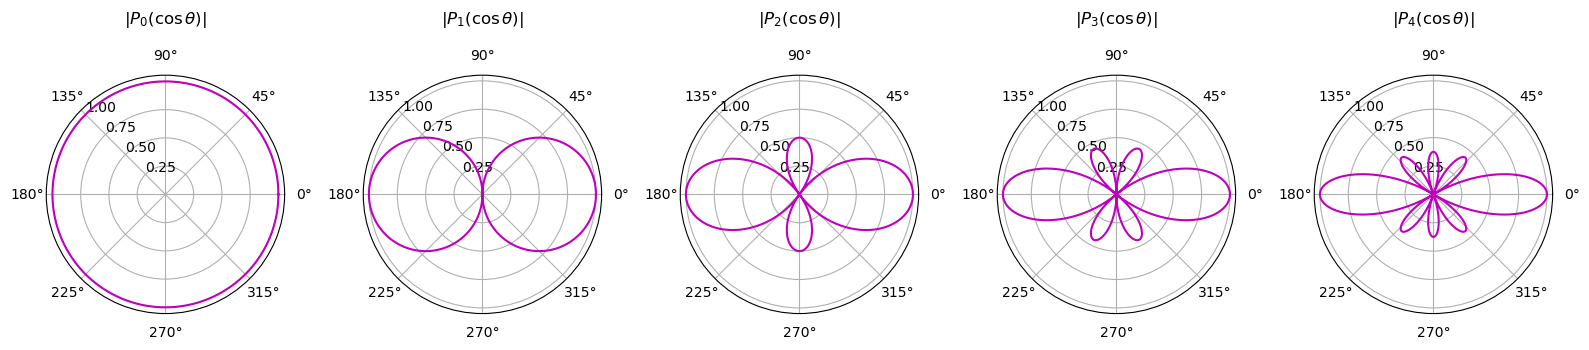

In [53]:
# Angular Legendre Polynomial Plots

# Angular coordinate
# We go from 0 to 2π so the full angular structure is visible
theta = np.linspace(0, 2*np.pi, 1000)

# Legendre polynomial orders to visualize
ells = [0, 1, 2, 3, 4]

# Create one polar subplot for each polynomial
fig, axes = plt.subplots(
    1,
    len(ells),
    figsize=(16, 4),
    subplot_kw={"projection": "polar"}
)

# Loop over each polynomial order
for ax, ell in zip(axes, ells):

    # Evaluate the Legendre polynomial P_ell(x)
    # with x = cos(theta)
    #
    # This substitution appears naturally in spherical
    # coordinate systems and angular eigenvalue problems
    P = ss.eval_legendre(ell, np.cos(theta))

    # Use the absolute value so negative regions
    # become visible outward lobes
    r = np.abs(P)

    # Plot the angular structure in polar coordinates
    ax.plot(
        theta,
        r,
        'm',
        linewidth=1.5
    )

    ax.set_title(
        rf"$|P_{{{ell}}}(\cos\theta)|$",
        pad=18
    )

    ax.set_rticks([0.25, 0.5, 0.75, 1.0])

    # Move radial labels away from the default position
    ax.set_rlabel_position(135)

    ax.grid(True)

plt.tight_layout()
plt.show()